 ## References

 *note that this is binary classification*

 MLP with pytorch at end

 * Data source: https://www.unsw.adfa.edu.au/unsw-canberra-cyber/cybersecurity/ADFA-NB15-Datasets/
 * Sample/starter code: https://github.com/Nir-J/ML-Projects/blob/master/UNSW-Network_Packet_Classification/unsw.py

In [ ]:
%%capture
!pip install mlxtend

In [ ]:
%config IPCompleter.greedy=True
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib as matplot
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings
warnings.filterwarnings("ignore")

from keras import Sequential
from keras.models import Model, load_model
from keras.layers import *
from keras.callbacks import ModelCheckpoint
from keras import regularizers

from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,normalize


import xgboost, lightgbm
from mlxtend.classifier import EnsembleVoteClassifier

# Preprocessing (transformation/scaling)

In [ ]:
train = pd.read_csv('https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv')
test = pd.read_csv('https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv')
combined_data = pd.concat([train, test]).drop(['id'],axis=1)

In [ ]:
# Contaminsation mean pollution (outliers) in data
tmp = train.where(train['attack_cat'] == "Normal").dropna()
contamination = round(1 - len(tmp)/len(train), 2)
print("train contamination ", contamination)

tmp = test.where(test['attack_cat'] == "Normal").dropna()
print("test  contamination ", round(1 - len(tmp)/len(test),2),'\n')

if contamination > 0.5:
    print(f'contamination is {contamination}, which is greater than 0.5. Fixing...')
    contamination = round(1-contamination,2)
    print(f'contamination is now {contamination}')

train contamination  0.68
test  contamination  0.55 

contamination is 0.68, which is greater than 0.5. Fixing...
contamination is now 0.32


In [ ]:
le1 = LabelEncoder()
le = LabelEncoder()

vector = combined_data['attack_cat']

print("attack cat:", set(list(vector))) # use print to make it print on single line

combined_data['attack_cat'] = le1.fit_transform(vector)
combined_data['proto'] = le.fit_transform(combined_data['proto'])
combined_data['service'] = le.fit_transform(combined_data['service'])
combined_data['state'] = le.fit_transform(combined_data['state'])

vector = combined_data['attack_cat']
print('\nDescribing attack_type: ')
print("min", vector.min())
print("max", vector.max())
print("mode",vector.mode(), "Which is,", le1.inverse_transform(vector.mode()))
print("mode", len(np.where(vector.values==6)[0])/len(vector),"%")

attack cat: {'Reconnaissance', 'DoS', 'Exploits', 'Worms', 'Analysis', 'Fuzzers', 'Normal', 'Generic', 'Backdoor', 'Shellcode'}

Describing attack_type: 
min 0
max 9
mode 0    6
Name: attack_cat, dtype: int64 Which is, ['Normal']
mode 0.3609225646458884 %


In [ ]:
le1.inverse_transform([0,1,2,3,4,5,6,7,8,9])
combined_data.head(3)

array(['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic',
       'Normal', 'Reconnaissance', 'Shellcode', 'Worms'], dtype=object)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,113,0,4,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,6,0
1,0.649902,113,0,4,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,6,0
2,1.623129,113,0,4,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,6,0


In [ ]:
## OMITTED: For statistical feature removal

lowSTD = list(combined_data.std().to_frame().nsmallest(6, columns=0).index)
# this is stupid. suppose a feature has a 1.0 (spearman or pearson) correlation, OR conditional probability, when not 0.... That a very useful feature

lowCORR = list(combined_data.corr().abs().sort_values('attack_cat')['attack_cat'].nsmallest(3).index) # .where(lambda x: x < 0.005).dropna()
# This might be stupid. A Deep MLP (feed forward neural net) may see patterns

drop = set( lowCORR + lowSTD)
drop = {'ackdat', 'ct_ftp_cmd', 'djit', 'is_ftp_login', 'is_sm_ips_ports', 'response_body_len', 'sjit', 'synack', 'tcprtt'}
print(f'Before {combined_data.shape}')
combined_data_reduced=combined_data # .drop(drop,axis=1)
# print(f'After {combined_data.shape}')

Before (257673, 44)


In [ ]:
# # transform = list(combined_data_reduced.columns.values[4:])
# transform.append('dur')
# transform.remove('attack_cat')
# # transform min-max norm
# combined_data_reduced[transform] = combined_data_reduced[transform].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

In [ ]:
data_x = combined_data_reduced.drop(['attack_cat','label'], axis=1) # droped label
data_y = combined_data_reduced.loc[:,['label']]
# del combined_data # free mem
X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=.20, random_state=42) # TODO

In [ ]:
#combined_data_reduced.where(combined_data_reduced['label'] == 1.0).dropna().tail(20)

In [ ]:
X_train.shape
y_train.shape
X_test.shape # test is larger... good
y_test.shape

(206138, 42)

(206138, 1)

(51535, 42)

(51535, 1)

# Benchmark before feature removal

In [ ]:
DTC = DecisionTreeClassifier()
RFC = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
ETC = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
XGB = xgboost.XGBClassifier(n_estimators=150, n_jobs=-1)
GBM = lightgbm.LGBMClassifier(objective='binary', n_estimators= 500) # multiclass

list_of_CLFs_names = []
list_of_CLFs = [DTC, RFC, ETC, XGB, GBM]
ranking = []

for clf in list_of_CLFs:
    _ = clf.fit(X_train, y_train)
    pred = clf.score(X_test, y_test)
    name = str(type(clf)).split(".")[-1][:-2]
    print("Acc: %0.5f for the %s" % (pred, name))

    ranking.append(pred)
    list_of_CLFs_names.append(name)

Acc: 0.93752 for the DecisionTreeClassifier
Acc: 0.95240 for the RandomForestClassifier
Acc: 0.95133 for the ExtraTreesClassifier
Acc: 0.95021 for the XGBClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028629 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6189
[LightGBM] [Info] Number of data points in the train set: 206138, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.639140 -> initscore=0.571633
[LightGBM] [Info] Start training from score 0.571633
Acc: 0.95199 for the LGBMClassifier


In [ ]:
# إعداد EnsembleVoteClassifier بدون المعامل 'refit'
eclf = EnsembleVoteClassifier(clfs=list_of_CLFs, voting='soft')

# تدريب النموذج
_ = eclf.fit(X_train, y_train)

# تقييم النموذج باستخدام مجموعة الاختبار
pred = eclf.score(X_test, y_test)

# طباعة النتيجة
print("Acc: %0.5f for the %s" % (pred, str(type(eclf)).split(".")[-1][:-2]))


[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6189
[LightGBM] [Info] Number of data points in the train set: 206138, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.639140 -> initscore=0.571633
[LightGBM] [Info] Start training from score 0.571633
Acc: 0.95275 for the EnsembleVoteClassifier


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA, TruncatedSVD, PCA
from sklearn.svm import LinearSVC
n = 10

### Try RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from mlxtend.classifier import EnsembleVoteClassifier

# تحديد عدد الميزات التي نريد اختيارها
n = 10

# تطبيق RFE لاختيار الميزات الأفضل باستخدام DecisionTreeClassifier
rfe = RFE(estimator=DecisionTreeClassifier(), n_features_to_select=n).fit(X_train, y_train)

# استخراج الفهارس للميزات المحددة
desiredIndices = np.where(rfe.support_==True)[0]
whitelist = X_train.columns.values[desiredIndices]

# تحديث بيانات التدريب والاختبار بناءً على الميزات المختارة
X_train_RFE, X_test_RFE = X_train[whitelist], X_test[whitelist]

# طباعة الشكل الجديد للبيانات
print('new shape', X_train_RFE.shape)

# قائمة لتخزين التصنيفات والتقييمات
ranking = []
list_of_CLFs_names = []

# تدريب وتقييم النماذج باستخدام الميزات المحددة
for clf in list_of_CLFs:
    _ = clf.fit(X_train_RFE, y_train)
    pred = clf.score(X_test_RFE, y_test)
    name = str(type(clf)).split(".")[-1][:-2]
    print("Acc: %0.5f for the %s" % (pred, name))

    ranking.append(pred)
    list_of_CLFs_names.append(name)

# تدريب نموذج التصنيف الجماعي
eclf = EnsembleVoteClassifier(clfs=list_of_CLFs, voting='soft')
_ = eclf.fit(X_train_RFE, y_train)

# تقييم التصنيف الجماعي
pred = eclf.score(X_test_RFE, y_test)
print("Acc: %0.5f for the %s" % (pred, str(type(eclf)).split(".")[-1][:-2]))

# التنبؤ باستخدام النموذج الجماعي
pred = eclf.predict(X_test_RFE)

# الحصول على الاحتمالات الخاصة بكل تصنيف
probas = eclf.predict_proba(X_test_RFE)


new shape (206138, 10)
Acc: 0.93430 for the DecisionTreeClassifier
Acc: 0.94842 for the RandomForestClassifier
Acc: 0.94441 for the ExtraTreesClassifier
Acc: 0.94462 for the XGBClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1913
[LightGBM] [Info] Number of data points in the train set: 206138, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.639140 -> initscore=0.571633
[LightGBM] [Info] Start training from score 0.571633
Acc: 0.94547 for the LGBMClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005769 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_

### Try SVD and PCA

In [ ]:
svd = TruncatedSVD(n_components=n).fit(X_train)
X_train_svd, X_test_svd = svd.transform(X_train), svd.transform(X_test)

for clf in list_of_CLFs:
    _ = clf.fit(X_train_svd, y_train)
    pred = clf.score(X_test_svd, y_test)
    name = str(type(clf)).split(".")[-1][:-2]
    print("Acc: %0.5f for the %s" % (pred, name))

    ranking.append(pred)
    list_of_CLFs_names.append(name)

eclf = EnsembleVoteClassifier(clfs=list_of_CLFs, voting='soft')

_ = eclf.fit(X_train_svd, y_train)
pred = eclf.score(X_test_svd, y_test)
print("Acc: %0.5f for the %s" % (pred, str(type(eclf)).split(".")[-1][:-2]))


pred = eclf.predict(X_test_svd)
probas = eclf.predict_proba(X_test_svd)

Acc: 0.88010 for the DecisionTreeClassifier
Acc: 0.89877 for the RandomForestClassifier
Acc: 0.89815 for the ExtraTreesClassifier
Acc: 0.88800 for the XGBClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 206138, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.639140 -> initscore=0.571633
[LightGBM] [Info] Start training from score 0.571633
Acc: 0.88973 for the LGBMClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data poin

Acc: 0.87686 for the DecisionTreeClassifier
Acc: 0.89246 for the RandomForestClassifier
Acc: 0.88949 for the ExtraTreesClassifier
Acc: 0.88167 for the XGBClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 206138, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.639140 -> initscore=0.571633
[LightGBM] [Info] Start training from score 0.571633
Acc: 0.88278 for the LGBMClassifier
[LightGBM] [Info] Number of positive: 131751, number of negative: 74387
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data poin

<Figure size 1000x600 with 0 Axes>

(array([10398.,   674.,   235.,   219.,   142.,   161.,   110.,   131.,
          137.,   134.,   169.,   173.,   210.,   217.,   202.,   197.,
          234.,   285.,   304.,   376.,   379.,   494.,   519.,   538.,
          509.,   495.,   429.,   380.,   363.,   415.,   475.,   557.,
          569.,   759.,   752.,   807.,   782.,   717.,   657.,   613.,
          585.,   577.,   571.,   550.,   535.,   577.,   542.,   555.,
          646., 20480.]),
 array([8.08425763e-09, 1.99997775e-02, 3.99995469e-02, 5.99993163e-02,
        7.99990857e-02, 9.99988551e-02, 1.19998625e-01, 1.39998394e-01,
        1.59998163e-01, 1.79997933e-01, 1.99997702e-01, 2.19997472e-01,
        2.39997241e-01, 2.59997010e-01, 2.79996780e-01, 2.99996549e-01,
        3.19996319e-01, 3.39996088e-01, 3.59995857e-01, 3.79995627e-01,
        3.99995396e-01, 4.19995166e-01, 4.39994935e-01, 4.59994704e-01,
        4.79994474e-01, 4.99994243e-01, 5.19994013e-01, 5.39993782e-01,
        5.59993551e-01, 5.79993321e-01

Text(0.5, 1.0, 'Probability Distribution for Class 1')

Text(0.5, 0, 'Probability')

Text(0, 0.5, 'Frequency')

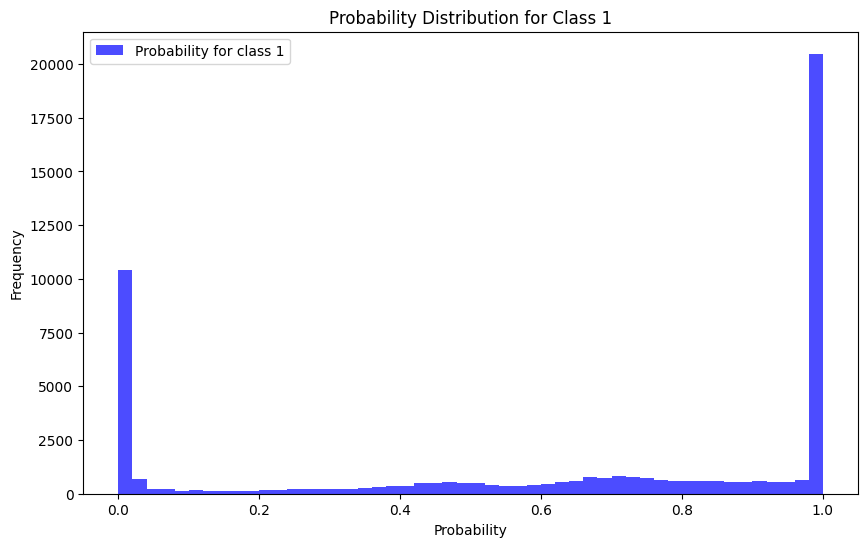

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix')

Text(0.5, 36.72222222222221, 'Predicted')

Text(70.72222222222221, 0.5, 'True')

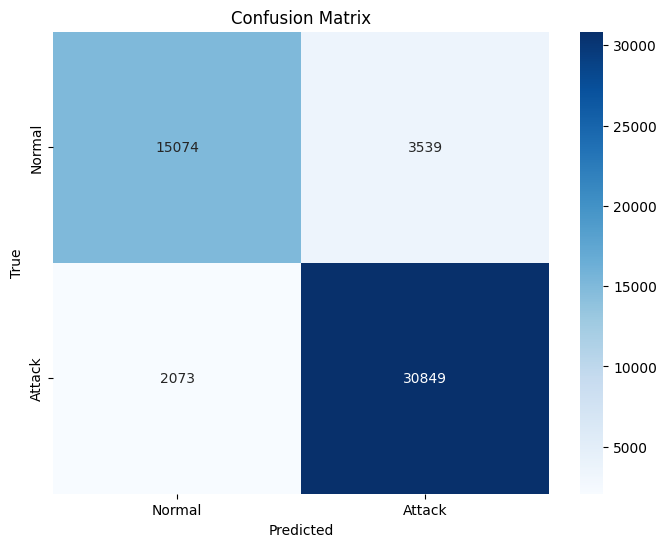

In [ ]:
from mlxtend.classifier import EnsembleVoteClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.decomposition import PCA

# تطبيق PCA
pca = PCA(n_components=n).fit(X_train)
X_train_pca, X_test_pca = pca.transform(X_train), pca.transform(X_test)

# قائمة لتخزين الترتيب والأسماء
ranking = []
list_of_CLFs_names = []

# تدريب النماذج الفردية وحساب الدقة
for clf in list_of_CLFs:
    _ = clf.fit(X_train_pca, y_train)
    pred = clf.score(X_test_pca, y_test)
    name = str(type(clf)).split(".")[-1][:-2]
    print("Acc: %0.5f for the %s" % (pred, name))

    ranking.append(pred)
    list_of_CLFs_names.append(name)

# تدريب نموذج التصويت التجميعي (Voting Classifier)
eclf = EnsembleVoteClassifier(clfs=list_of_CLFs, voting='soft')  # تم إزالة refit
_ = eclf.fit(X_train_pca, y_train)

# تقييم دقة نموذج التصويت التجميعي
pred = eclf.score(X_test_pca, y_test)
print("Acc: %0.5f for the %s" % (pred, str(type(eclf)).split(".")[-1][:-2]))

# التنبؤات والاحتمالات
pred = eclf.predict(X_test_pca)
probas = eclf.predict_proba(X_test_pca)

# رسم توزيع الاحتمالات
plt.figure(figsize=(10, 6))
plt.hist(probas[:, 1], bins=50, alpha=0.7, color='blue', label='Probability for class 1')
plt.title('Probability Distribution for Class 1')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend(loc='best')
plt.show()

# حساب وعرض مصفوفة الارتباك
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
